# 条件质心可视化

面向 `trishift / scouter / gears / genepert` 的 condition centroid 级别可视化。

这个 notebook 会完成以下工作：
- 对每个 condition 计算 `DE` 特征空间中的质心
- 比较每个 condition 下 `Truth / Pred / Ctrl` 的 centroid
- 输出 centroid UMAP、delta-centroid UMAP 以及对应统计结果

默认约定如下：
- `trishift/scouter` 默认推荐使用 `variant_tag="nearest"`
- `gears/genepert` 不需要设置 `variant_tag`
- `feature_mode="full"` 需要结果 `pkl` 中包含 full-gene 特征；否则请使用默认的 `deg`


In [19]:
from __future__ import annotations

import importlib
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

repo_root = Path.cwd()
if not (repo_root / "scripts").exists() and (repo_root.parent / "scripts").exists():
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

import scripts.trishift.analysis.condition_centroid_vis as condition_centroid_vis
importlib.reload(condition_centroid_vis)

run_condition_centroid_visualization = condition_centroid_vis.run_condition_centroid_visualization

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
repo_root


WindowsPath('e:/CODE/trishift')

## 参数

在这里设置模型、数据集、split，以及输出目录和 UMAP 作图参数。


In [20]:
model_name = "genepert"  # 可选: trishift | scouter | gears | genepert
dataset = "adamson"
split_id = 1
result_dir = None
out_root = None
variant_tag = ""  # trishift/scouter 可选: nearest / random / None
feature_mode = "deg"  # 特征模式: deg | full
include_ctrl = True
plot_delta = True
umap_n_neighbors = None
umap_min_dist = 0.15
save_dpi = 420
seed = 24

run_kwargs = dict(
    model_name=model_name,
    dataset=dataset,
    split_id=split_id,
    result_dir=result_dir,
    out_root=out_root,
    variant_tag=variant_tag,
    feature_mode=feature_mode,
    include_ctrl=include_ctrl,
    plot_delta=plot_delta,
    umap_n_neighbors=umap_n_neighbors,
    umap_min_dist=umap_min_dist,
    save_dpi=save_dpi,
    seed=seed,
)
run_kwargs


{'model_name': 'genepert',
 'dataset': 'adamson',
 'split_id': 1,
 'result_dir': None,
 'out_root': None,
 'variant_tag': '',
 'feature_mode': 'deg',
 'include_ctrl': True,
 'plot_delta': True,
 'umap_n_neighbors': None,
 'umap_min_dist': 0.15,
 'save_dpi': 420,
 'seed': 24}

In [21]:
result = run_condition_centroid_visualization(**run_kwargs)
print(f"out_dir: {result.out_dir}")
display(result.summary_df)
display(result.metrics_df.head(20))
display(result.points_df.head(20))


d:\conda_envs\scouter\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
d:\conda_envs\scouter\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


out_dir: E:\CODE\trishift\artifacts\results\genepert\adamson\condition_centroid_plots


,n_conditions,n_splits,centroid_dist_mean,centroid_dist_median,centroid_dist_std,delta_centroid_dist_mean,delta_centroid_dist_median,delta_centroid_dist_std,centroid_cosine_mean,centroid_cosine_median,centroid_cosine_std,delta_cosine_mean,delta_cosine_median,delta_cosine_std,truth_ctrl_shift_norm_mean,truth_ctrl_shift_norm_median,truth_ctrl_shift_norm_std,pred_ctrl_shift_norm_mean,pred_ctrl_shift_norm_median,pred_ctrl_shift_norm_std,model_name,dataset,split_id,feature_mode,variant_tag,include_ctrl,plot_delta,umap_n_neighbors,umap_min_dist,embed_mode
0,17,1,1.092259,0.605314,1.036716,1.092259,0.605314,1.036716,0.99418,0.998879,0.010398,0.87068,0.971882,0.354955,2.410951,2.057837,0.833332,1.629149,1.635795,0.21257,genepert,adamson,1,deg,,True,True,15,0.15,umap


,split_id,condition,feature_mode_used,feature_dim,n_truth,n_pred,n_ctrl,centroid_dist,centroid_cosine,truth_ctrl_shift_norm,pred_ctrl_shift_norm,delta_centroid_dist,delta_cosine
0,1,ATP5B+ctrl,deg,19,547,547,547,0.317938,0.999713,1.902325,1.781461,0.317938,0.987241
1,1,BHLHE40+ctrl,deg,19,504,504,504,3.975272,0.964571,3.377047,1.011213,3.975272,-0.494272
2,1,CARS+ctrl,deg,19,429,429,429,2.966548,0.972307,4.732963,1.893379,2.966548,0.958869
3,1,CCND3+ctrl,deg,19,310,310,310,1.174808,0.996952,2.290391,1.436755,1.174808,0.901013
4,1,COPB1+ctrl,deg,20,185,185,185,0.605314,0.998879,2.094140,1.737593,0.605314,0.967121
5,1,DERL2+ctrl,deg,19,542,542,542,0.433448,0.999772,1.868292,1.490085,0.433448,0.991947
6,1,HARS+ctrl,deg,19,272,272,272,2.148300,0.985529,3.936583,1.887862,2.148300,0.971882
7,1,HYOU1+ctrl,deg,19,432,432,432,0.496738,0.999491,1.919304,1.567777,0.496738,0.979532
8,1,MANF+ctrl,deg,19,462,462,462,0.465509,0.999555,2.006063,1.635795,0.465509,0.987871
9,1,MRPL39+ctrl,deg,19,582,582,582,0.341558,0.999636,1.865952,1.723864,0.341558,0.985004


,split_id,condition,kind,feature_mode_used,feature_dim,n_truth,n_pred,n_ctrl,umap1,umap2
0,1,ATP5B+ctrl,Truth,deg,19,547,547,547,-8.923889,8.665903
1,1,ATP5B+ctrl,Pred,deg,19,547,547,547,-9.455480,9.145500
2,1,ATP5B+ctrl,Ctrl,deg,19,547,547,547,-9.221951,8.416053
3,1,BHLHE40+ctrl,Truth,deg,19,504,504,504,-12.910766,7.366498
4,1,BHLHE40+ctrl,Pred,deg,19,504,504,504,-12.690171,7.403082
5,1,BHLHE40+ctrl,Ctrl,deg,19,504,504,504,-12.367640,7.185437
6,1,CARS+ctrl,Truth,deg,19,429,429,429,-8.576306,9.309494
7,1,CARS+ctrl,Pred,deg,19,429,429,429,-8.673965,9.061711
8,1,CARS+ctrl,Ctrl,deg,19,429,429,429,-8.951870,9.677548
9,1,CCND3+ctrl,Truth,deg,19,310,310,310,-10.800269,8.886182


## 图像

这里展示生成的 centroid UMAP 和 delta-centroid UMAP 图。


truth_vs_pred_centroid_umap E:\CODE\trishift\artifacts\results\genepert\adamson\condition_centroid_plots\truth_vs_pred_centroid_umap.png


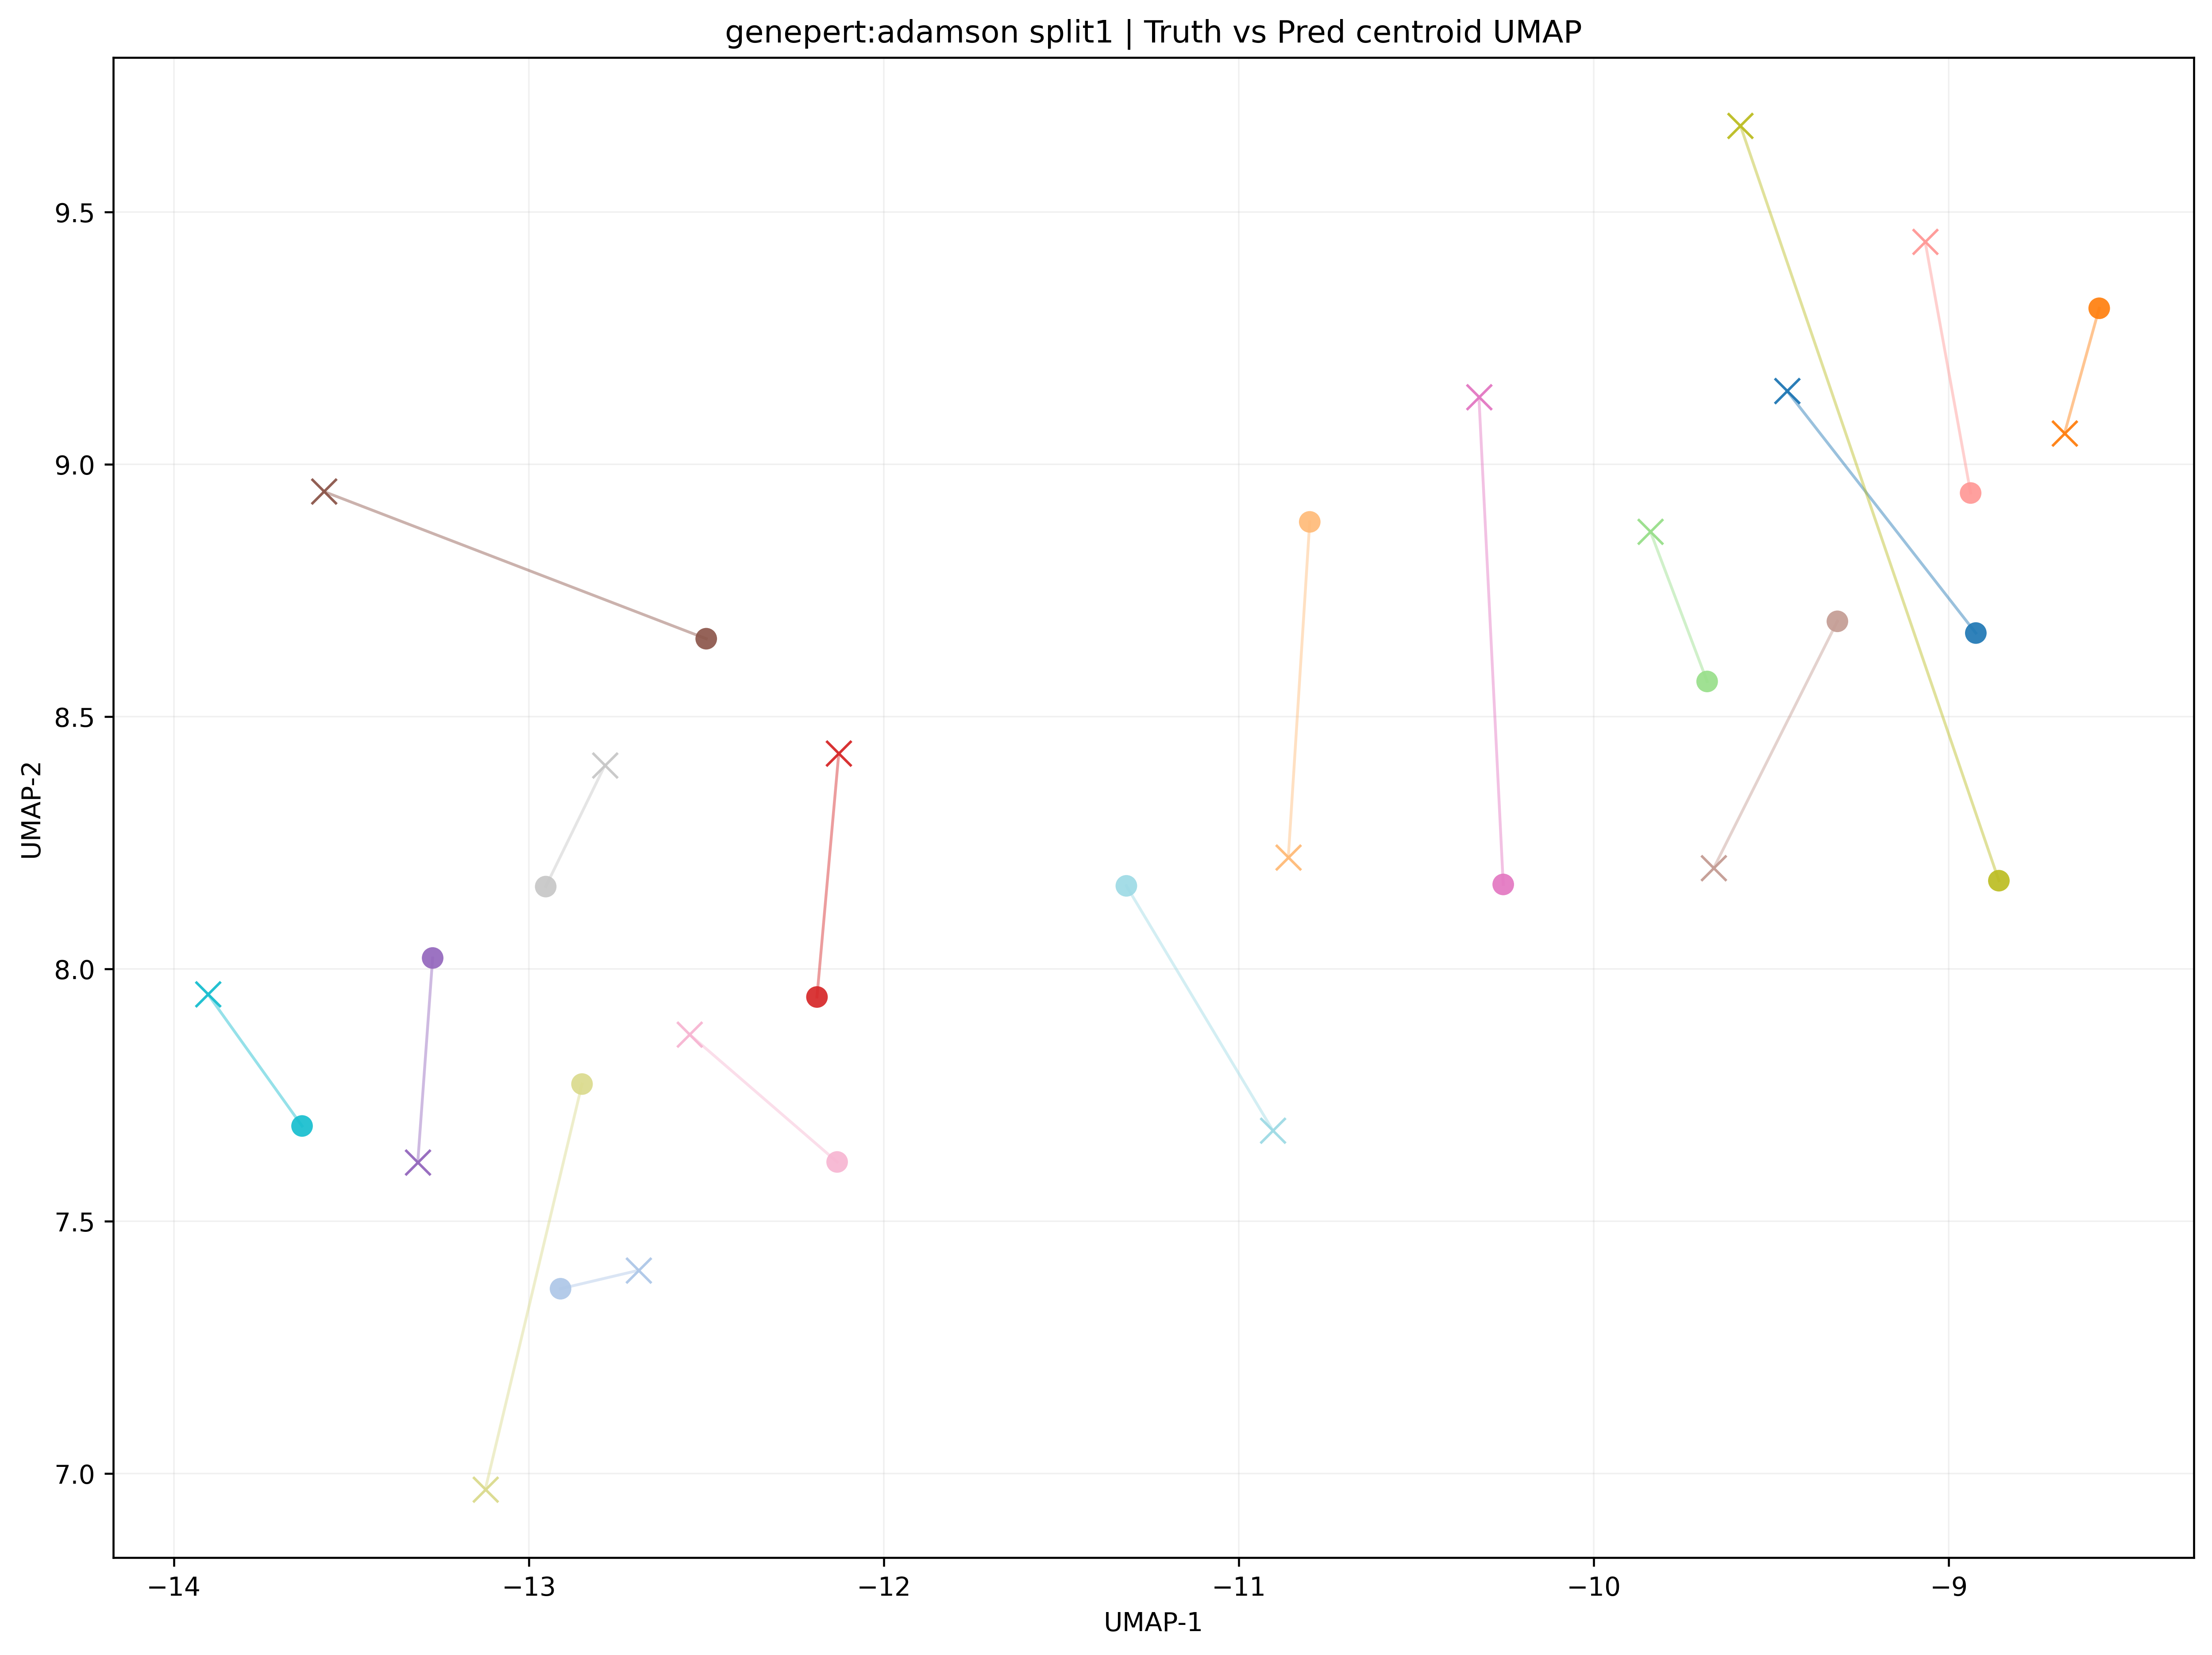

truth_pred_ctrl_centroid_umap E:\CODE\trishift\artifacts\results\genepert\adamson\condition_centroid_plots\truth_pred_ctrl_centroid_umap.png


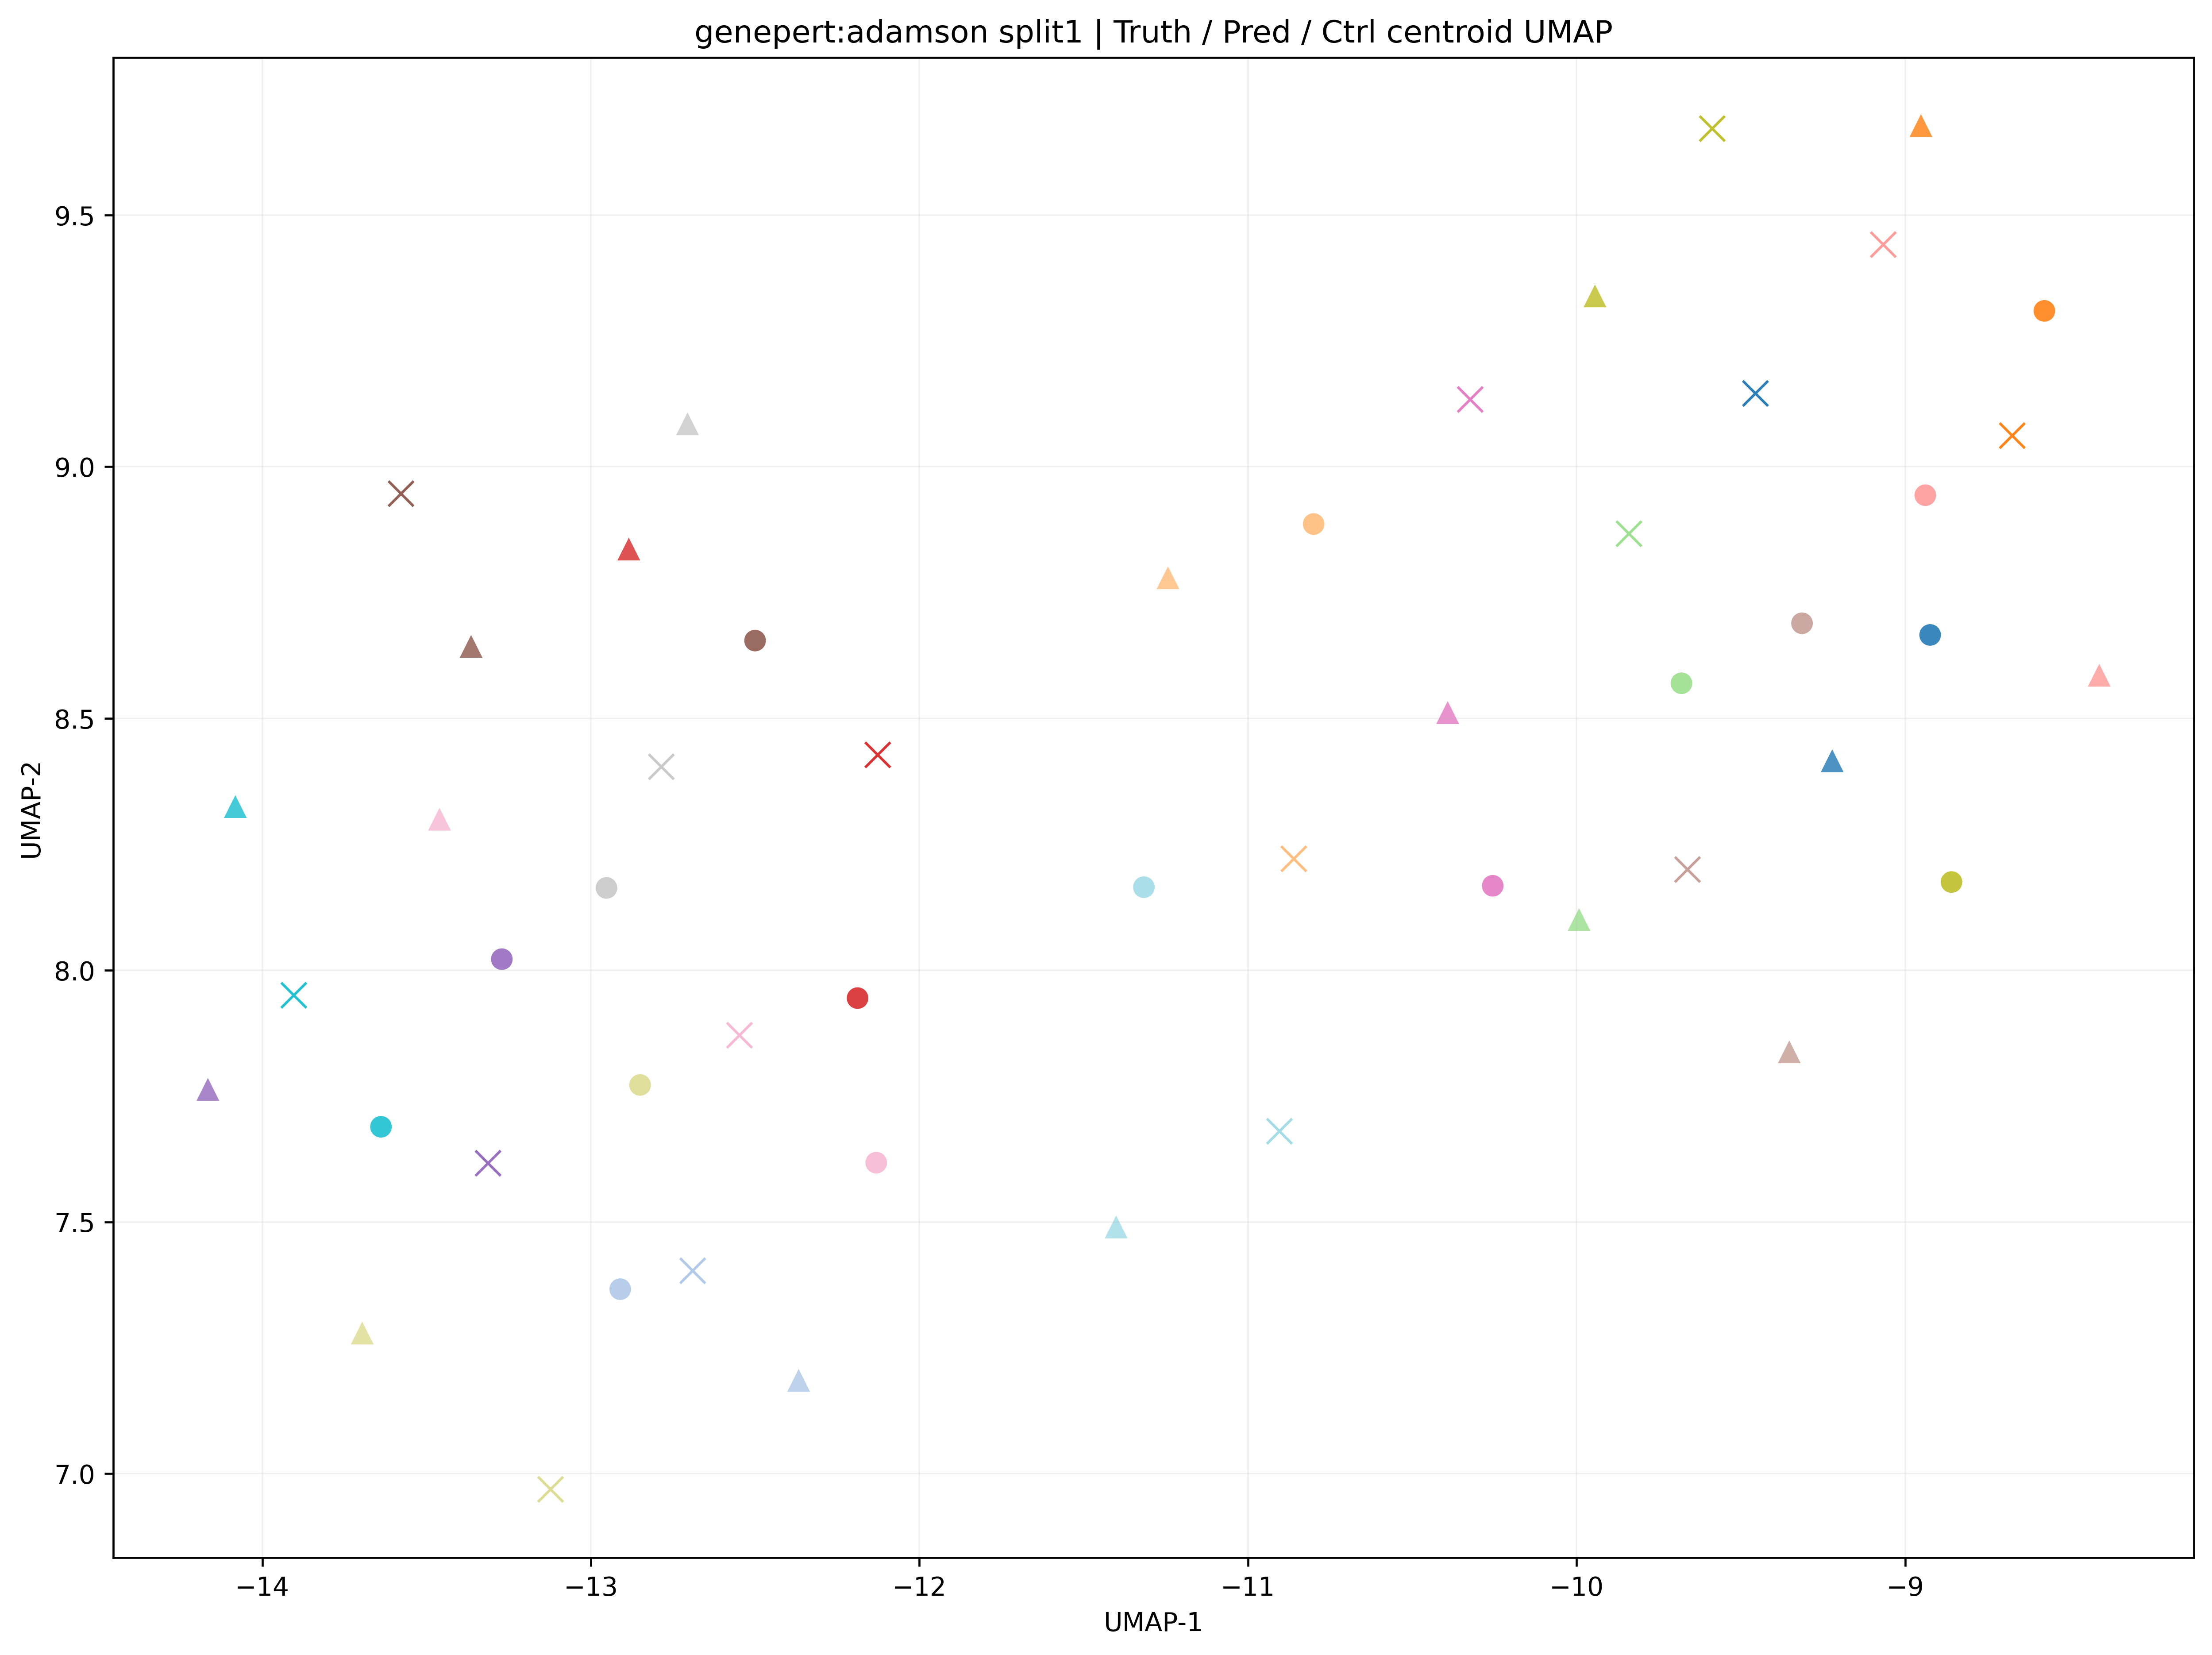

delta_centroid_umap E:\CODE\trishift\artifacts\results\genepert\adamson\condition_centroid_plots\delta_centroid_umap.png


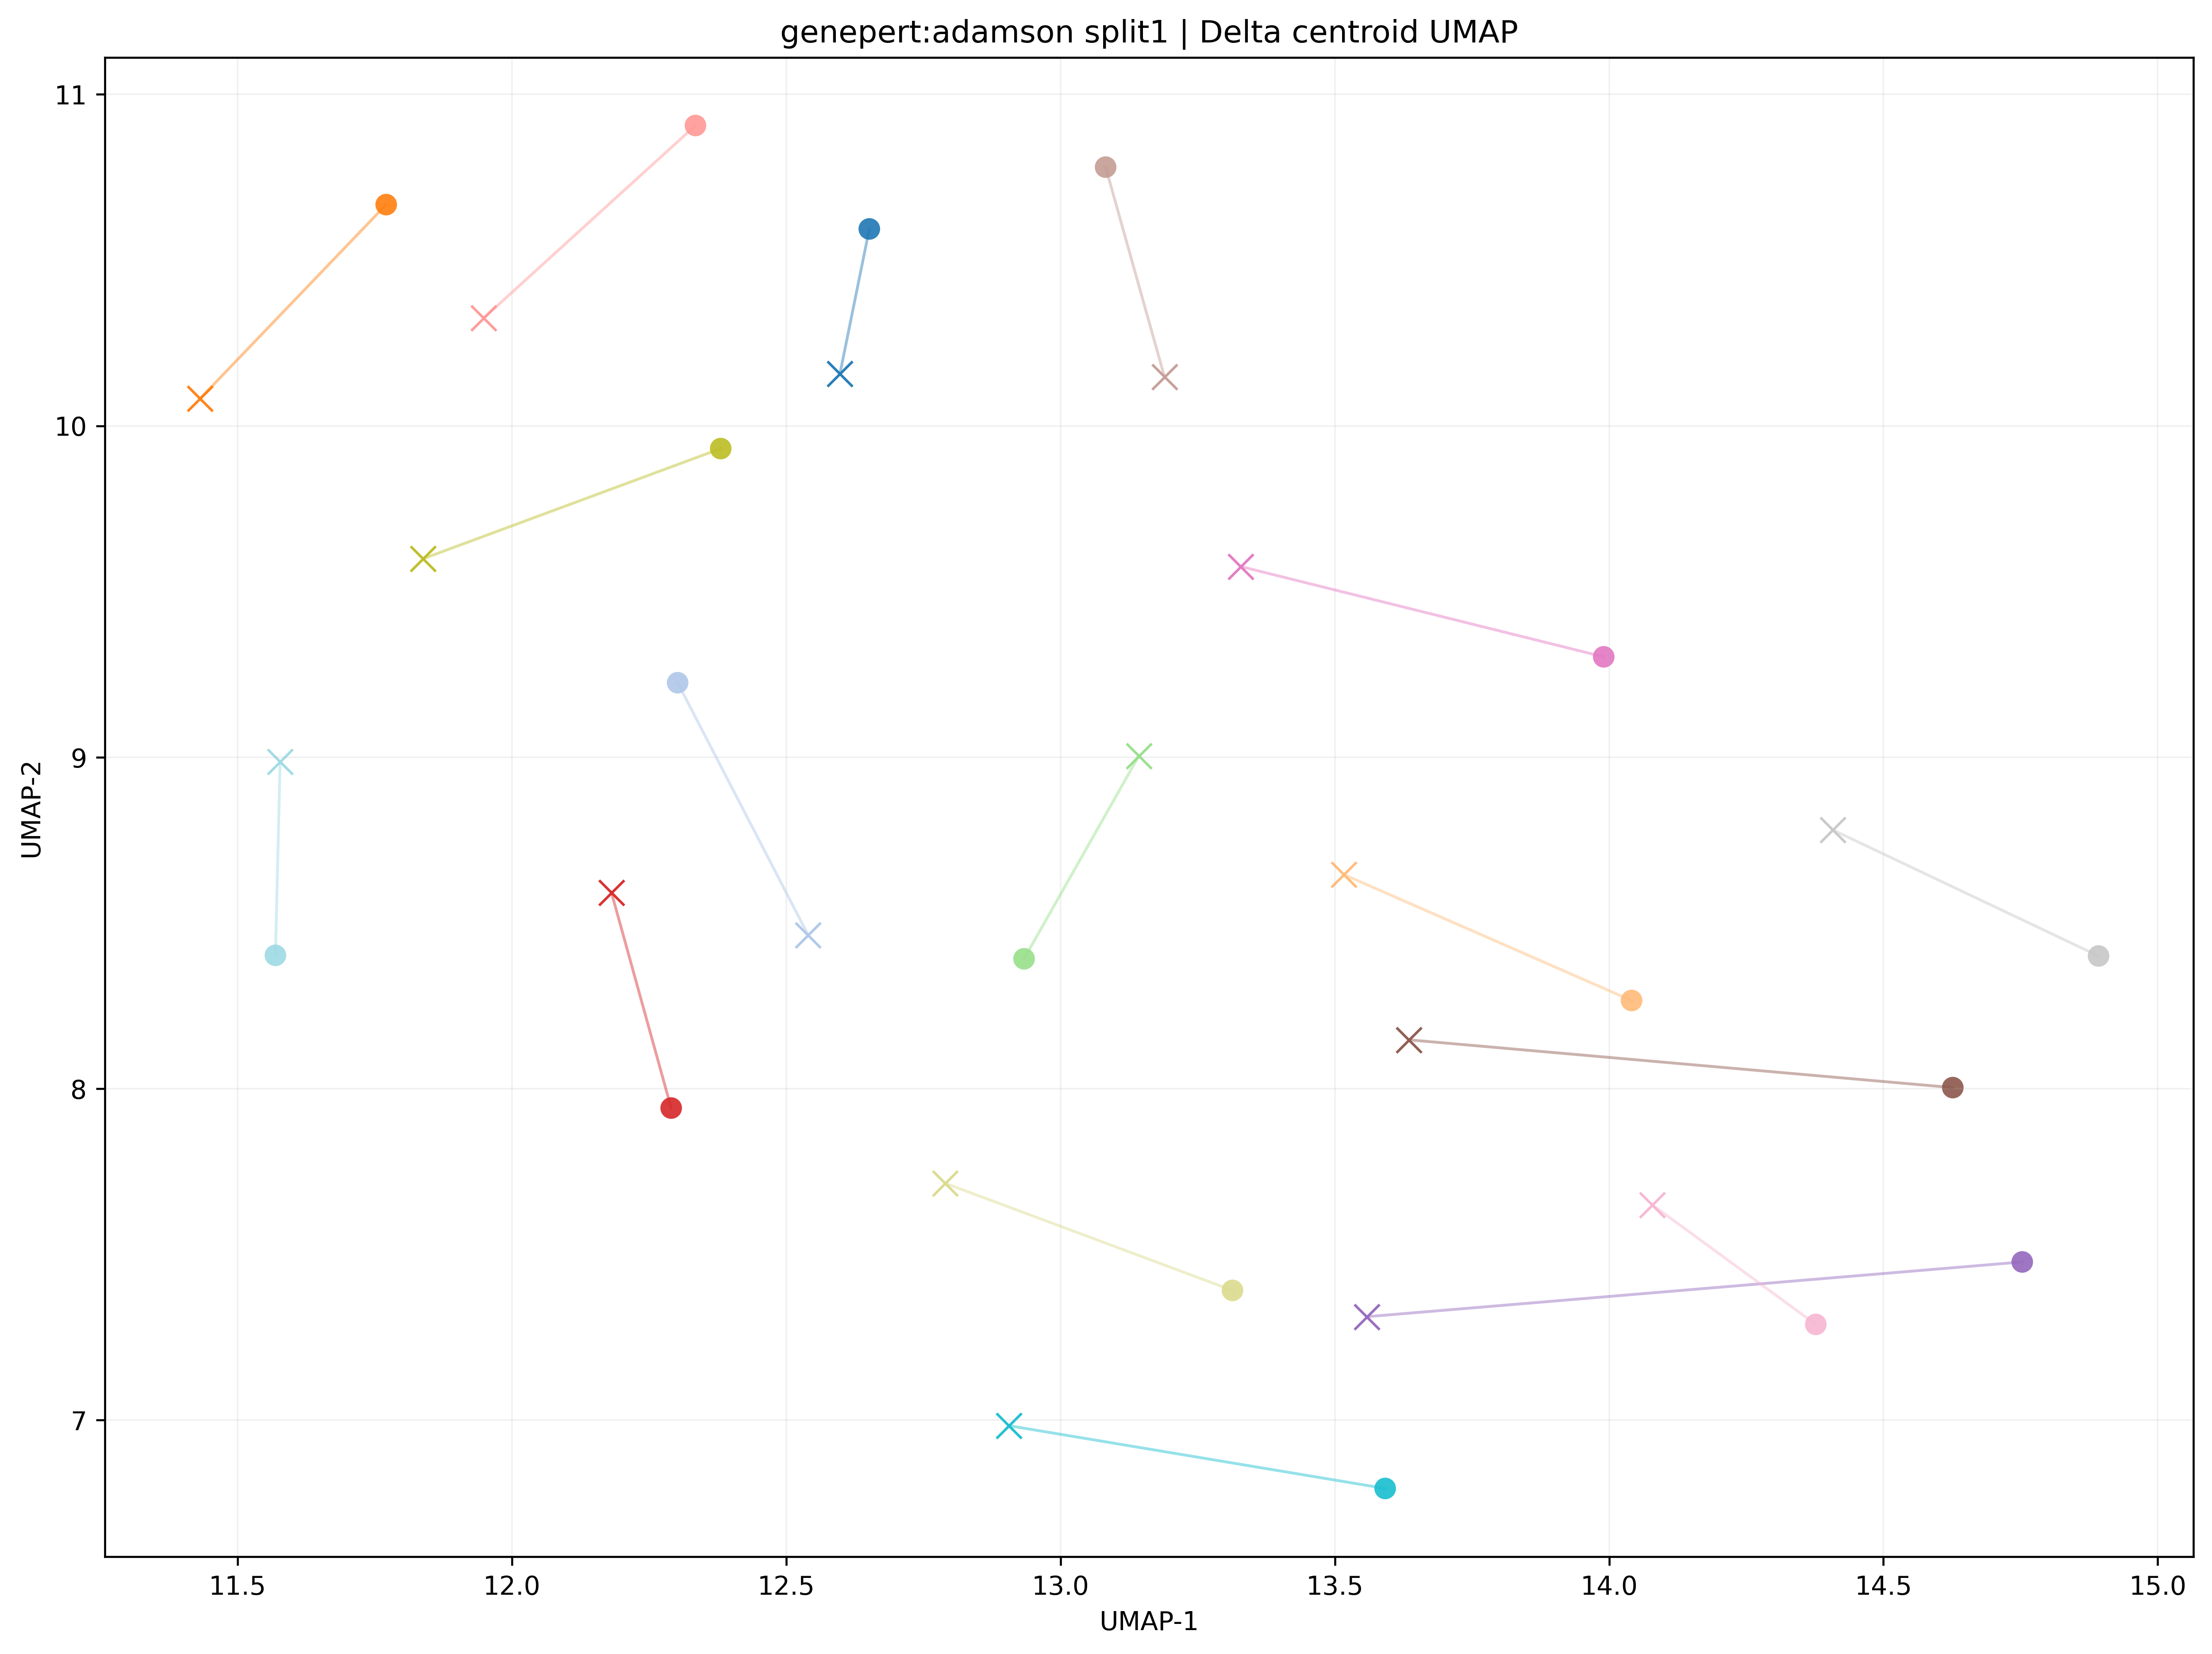

In [22]:
for key in ["truth_vs_pred_centroid_umap", "truth_pred_ctrl_centroid_umap", "delta_centroid_umap"]:
    img_path = result.figure_paths.get(key)
    if not img_path:
        continue
    print(key, img_path)
    display(Image(filename=img_path, width=1100))


## 输出文件

这里会打印本次运行生成的 CSV、图像和元信息文件路径。


In [23]:
print(result.out_dir / "condition_centroid_points.csv")
print(result.out_dir / "condition_centroid_metrics.csv")
print(result.out_dir / "condition_centroid_summary.csv")
print(result.out_dir / "run_meta.json")


E:\CODE\trishift\artifacts\results\genepert\adamson\condition_centroid_plots\condition_centroid_points.csv
E:\CODE\trishift\artifacts\results\genepert\adamson\condition_centroid_plots\condition_centroid_metrics.csv
E:\CODE\trishift\artifacts\results\genepert\adamson\condition_centroid_plots\condition_centroid_summary.csv
E:\CODE\trishift\artifacts\results\genepert\adamson\condition_centroid_plots\run_meta.json
